# Vortex Navigation, and the Role of `beta`

A localized vortex wind on the sphere is a useful test for time-optimal navigation. We compare the great-circle route with the wind-aware **Randers geodesic**, draw the wind field and the **indicatrix** it induces, and clarify what the AVBD solver's `beta` parameter controls. The 3-D scenes are interactive — drag to rotate and inspect the solution from any angle.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Euclidean, Randers, Sphere
from ham.solvers import AVBDSolver
from ham.vis import generate_icosphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
jax.config.update("jax_enable_x64", False)
key = jax.random.PRNGKey(0)
sphere = Sphere(radius=1.0)

## 2. A smooth vortex field

We model a swirl concentrated at a core $c$: the wind rotates around $c$ (the $c \times x$ direction)
with magnitude decaying away from the core. The radial profile $\exp(-\kappa(1-\langle x,c\rangle))$ is
smooth everywhere; we avoid `arccos`, whose infinite slope at the core would inject NaNs into the path
gradients.

In [2]:
def vortex_field(center, strength=2.5, decay=6.0):
    center = center / jnp.linalg.norm(center)

    def flow(x):
        magnitude = strength * jnp.exp(-decay * (1.0 - jnp.dot(x, center)))
        return magnitude * jnp.cross(center, x)

    return flow


vortex_core = jnp.array([0.0, 0.0, 1.0])
w_net = vortex_field(vortex_core, strength=2.5, decay=6.0)


def h_net(x):
    return jnp.eye(3)


metric_randers = Randers(sphere, h_net, w_net)
metric_riem = Randers(sphere, h_net, lambda x: jnp.zeros(3))   # same sea, no wind

The `Randers` class squashes the raw wind with $\tilde W = (1-\varepsilon)\tanh(\|W\|)\,W/\|W\|$ so the
causality bound $\|W\|_h < 1$ holds everywhere, keeping $F$ in $C^1$ and strongly convex.

## 3. Great circle vs. wind-aware geodesic

We travel across the sphere on a route passing over the vortex core. The Riemannian geodesic is the
great circle (wind-blind); the Randers geodesic bends to use the swirl. Both come from the same solver
call.

In [3]:
start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([-1.0, 0.0, 0.2]); end = end / jnp.linalg.norm(end)

solver = AVBDSolver(step_size=0.05, beta=10.0, iterations=400)
traj_riem = solver.solve(metric_riem, start, end, n_steps=50, key=key)
traj_rand = solver.solve(metric_randers, start, end, n_steps=50, key=key)

batch_E = jax.vmap(metric_randers.energy)
e_riem = float(batch_E(traj_riem.xs[:-1], traj_riem.vs).sum())
e_rand = float(batch_E(traj_rand.xs[:-1], traj_rand.vs).sum())
print(f"travel energy of the great circle (under wind): {e_riem:.4f}")
print(f"travel energy of the Randers geodesic         : {e_rand:.4f}")
print(f"the wind-aware route costs {100 * (1 - e_rand / e_riem):.0f}% less")

travel energy of the great circle (under wind): 0.1718
travel energy of the Randers geodesic         : 0.1119
the wind-aware route costs 35% less


## 4. The wind field and the two routes

We sample the vortex over the sphere and draw it as a cone field; cone size follows the wind speed, so
the swirl shows as concentrated at the core and fading outward. Rotate the figure to follow the red
Randers geodesic leaning into the swirl while the great circle runs straight over the top.

In [4]:
pts, _ = generate_icosphere(radius=1.0, subdivisions=3)
pts = np.array(pts)
W = np.array(jax.vmap(lambda p: sphere.to_tangent(p, w_net(p)))(jnp.array(pts)))
keep = np.linalg.norm(W, axis=1) > 0.03

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_cones(pts[keep], W[keep], name="wind", sizeref=0.35,
                           showscale=True, colorbar_title="wind speed"))
fig.add_trace(plotly_path(traj_riem.xs, color=PALETTE["muted"], name="great circle",
                          width=5, dash="dash"))
fig.add_trace(plotly_path(traj_rand.xs, color=PALETTE["accent"], name="Randers geodesic", width=8))
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[1], mode="markers",
                           marker=dict(size=4, color=PALETTE["ink"]), name="vortex core"))
plotly_layout(fig, "Vortex navigation on the sphere")
fig.show()

## 5. The wind as a shifted indicatrix

The Randers metric encodes the wind by shifting the indicatrix (the velocities reachable in unit time).
The Riemannian indicatrix is a centred circle; the Randers one is an off-centre ellipse pushed along the
wind, so travelling with the wind reaches farther for the same cost. We draw both in the tangent plane
near the core.

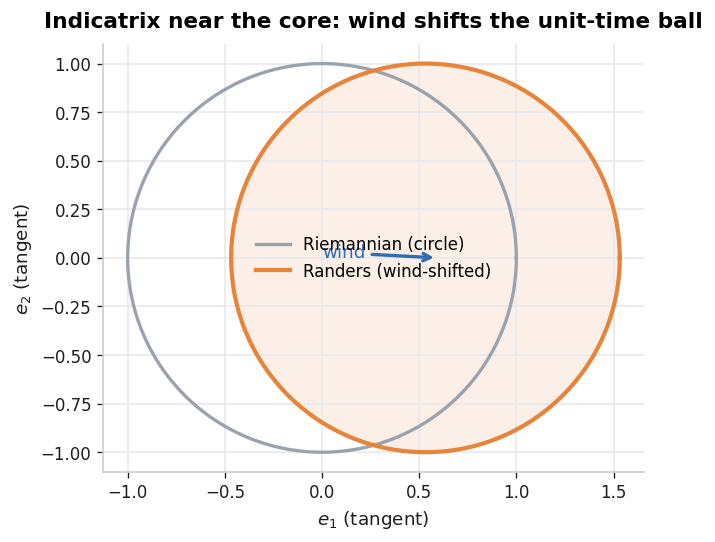

In [5]:
p = jnp.array([0.45, 0.0, 0.9]); p = p / jnp.linalg.norm(p)
e1 = sphere.to_tangent(p, jnp.array([0.0, 1.0, 0.0])); e1 = e1 / jnp.linalg.norm(e1)
e2 = sphere.to_tangent(p, jnp.cross(np.array(p), np.array(e1))); e2 = e2 / jnp.linalg.norm(e2)
ths = np.linspace(0, 2 * np.pi, 220)


def indicatrix(metric):
    rad = np.array([1.0 / float(metric.metric_fn(p, jnp.cos(t) * e1 + jnp.sin(t) * e2)) for t in ths])
    return rad * np.cos(ths), rad * np.sin(ths)


xr, yr = indicatrix(metric_riem)
xw, yw = indicatrix(metric_randers)
wv = np.array(sphere.to_tangent(p, w_net(p)))
wc = np.array([np.dot(wv, np.array(e1)), np.dot(wv, np.array(e2))])

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot(xr, yr, color=PALETTE["muted"], lw=2, label="Riemannian (circle)")
ax.fill(xw, yw, color=PALETTE["accent"], alpha=0.12)
ax.plot(xw, yw, color=PALETTE["accent"], lw=2.5, label="Randers (wind-shifted)")
ax.annotate("wind", xy=(wc[0], wc[1]), xytext=(0, 0), color=PALETTE["primary"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=2))
ax.set_aspect("equal"); ax.legend()
ax.set_title("Indicatrix near the core: wind shifts the unit-time ball")
ax.set_xlabel("$e_1$ (tangent)"); ax.set_ylabel("$e_2$ (tangent)")
plt.tight_layout(); plt.show()

## 6. What `beta` controls

A natural experiment is to sweep `beta` expecting the path to change in "stiffness". It does not — and
that is expected. `beta` is the growth factor for the Augmented-Lagrangian penalty on **constraints**
(see the dual-update block in `avbd.py`). Every section above passed no constraints, so that branch is
skipped and `beta` has no effect; it is not a path-rigidity control.

To see `beta` at work, we add a constraint: forbid a geodesic **cap around the vortex core** and measure
how quickly the constraint violation is driven to zero for different `beta`. A larger `beta` ramps the
penalty faster, enforcing the keep-out in fewer iterations.

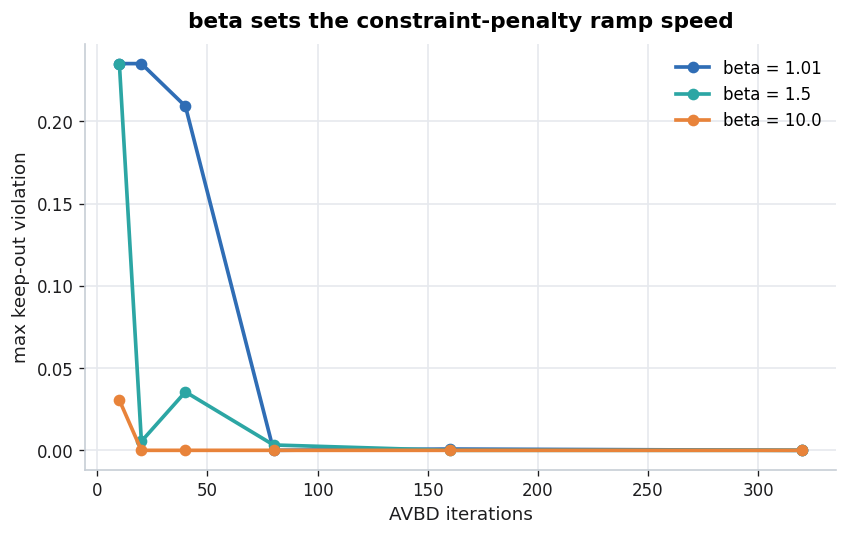

With no constraints, beta is inert, which is why an unconstrained sweep shows no change.


In [6]:
cap_cos = float(np.cos(0.7))


def keep_out(x):
    cd = jnp.dot(x / jnp.linalg.norm(x), vortex_core)
    return jax.nn.relu(cd - cap_cos)


s_in = jnp.array([0.8, 0.0, 0.6]); s_in = s_in / jnp.linalg.norm(s_in)
e_in = jnp.array([-0.8, 0.0, 0.6]); e_in = e_in / jnp.linalg.norm(e_in)
em = Euclidean(sphere)
iters = [10, 20, 40, 80, 160, 320]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for beta, col in [(1.01, PALETTE["primary"]), (1.5, PALETTE["teal"]), (10.0, PALETTE["accent"])]:
    viol = []
    for it in iters:
        tr = AVBDSolver(step_size=0.05, beta=beta, iterations=it, tol=1e-9).solve(
            em, s_in, e_in, n_steps=40, constraints=[keep_out], train_mode=True, key=key)
        viol.append(float(tr.constraint_violation))
    ax.plot(iters, viol, "-o", color=col, label=f"beta = {beta}")
ax.set_xlabel("AVBD iterations"); ax.set_ylabel("max keep-out violation")
ax.set_title("beta sets the constraint-penalty ramp speed")
ax.legend(); plt.tight_layout(); plt.show()
print("With no constraints, beta is inert, which is why an unconstrained sweep shows no change.")

## 7. Notes

* The Randers geodesic uses the vortex to reduce travel cost relative to the great circle — the
  geometric result, from a single solver call.
* The wind appears geometrically as a shifted indicatrix; drawing the full field (not a single slice)
  makes the swirl and the path's response legible.
* `beta` is the constraint-penalty growth factor, not a path-stiffness control. With no constraints it
  does nothing; with a keep-out constraint, a larger `beta` reaches feasibility in fewer iterations.